### 7. 딥러닝을 시작합니다
#### 7-1. 인공 신경망 


In [1]:
import keras
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()

2025-11-28 09:17:18.616956: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 09:17:18.628489: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764289038.642593   27266 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764289038.646773   27266 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-28 09:17:18.660845: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

**keras.datasets.fashion_mnist.load_data()** 이미 학습용·테스트용으로 분리된 데이터를 바로 반환

데이터는 입력과 타깃의 쌍으로 구성

In [2]:
# 데이터 크기 확인
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [3]:
# 테스트 세트 크기 확인
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


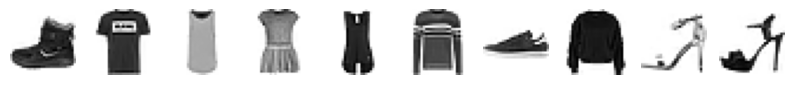

In [4]:
# 샘플 이미지 확인
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    axs[i].axis('off')
plt.show()   

In [5]:
# 처음 10개 샘플의 타깃값 확인
print(train_target[:10])

[9 0 0 3 0 2 7 2 5 5]


패션 MNIST의 타깃은 0~9까지의 숫자 레이블로 구성

|레이블|0|1|2|3|4|5|6|7|8|9|
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
|패션 아이템|티셔츠|바지|스웨터|드레스|코트|샌달|셔츠|스니커즈|가방|앵클 부츠|

In [6]:
# 레이블 당 샘플 개수 확인
# return_Counts=True: 각 고유 원소가 등장한 총 횟수를 나타내는 정보를 추가
import numpy as np
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


---

##### 로지스틱 회귀로 패션 아이템 분류하기

In [7]:
# reshape(): 2차원 배열인 각 샘플을 1차원 배열로 변환
# SGDClassifier는 2차원 입력을 다루지 못함
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)

In [8]:
print(train_scaled.shape)

(60000, 784)


In [9]:
# 성능 확인
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing ma

0.8194166666666666


/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [10]:
# 반복 횟수 변경 (1)
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing ma

0.8311666666666667


In [11]:
# 반복 횟수 변경 (2)
sc = SGDClassifier(loss='log_loss', max_iter=20, random_state=42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ai_study/miniconda3/envs/ai-study/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing ma

0.8437333333333334


패션 MNIST에서 로지스틱 회귀의 구조 <br>
→ 784개 픽셀로 10개의 선형식을 만들고, 소프트맥스로 확률을 계산

SGDClassifier 모델은 패션 MNIST 데이터의 클래스를 가능한 잘 구분할 수 있도록 이 10개의 방정식에 대한 모델 파라미터(가중치와 절편)를 찾음

---

##### 인공 신경망

- 입력층(Input layer)

    모델에 들어오는 **원본 특성(입력 데이터)** 를 받는 층

- 출력층(Output layer)

    모델이 최종적으로 예측 결과를 내는 층

- 뉴런(Neuron), 유닛(Unit)

    인공신경망의 기본 단위

In [12]:
# tensorflow: 구글이 11월 오픈소스로 공개한 딥러닝 라이브러리
# keras: 텐서플로의 고수준 API
import tensorflow as tf
import keras

딥러닝 라이브러리는 **GPU**를 사용하여 인공 신경망을 훈련

GPU는 벡터와 행렬 연산에 매우 최적화되어 있기 떄문에 곱셈과 덧셈이 많이 수행되는 인공 신경망에 큰 도움이 됨

In [13]:
# 케라스가 사용중인 백엔드를 확인
keras.config.backend()

'tensorflow'

케라스의 백엔드를 바꾸고 싶다면?

```python
import os
os.environ["KERAS_BACKEND"] = "torch" # 또는 "jax"

---

##### 인공 신경망으로 모델 만들기

딥러닝 분야의 데이터셋은 충분히 크기 때문에 검증 점수가 안정적이고, 

교차 검증을 수행하기에는 훈련 시간이 너무 오래 걸리기 때문에

인공 신경망에서는 교차 검증을 잘 사용하지 않고 **검증 세트를 별도로 덜어내어 사용**

In [14]:
# 훈련 세트와 검증 세트 구분
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [15]:
# 훈련 세트 크기 확인
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [16]:
# 검증 세트 크기 확인
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


신경망 알고리즘은 입력의 크기에 따라 모델의 가중치가 결정되는 경우가 많으므로 종종 **입력층**이라는 개념을 도입

In [17]:
# 입력층 정의
inputs = keras.layers.Input(shape=(784,))        # 내장 함수와 변수명이 중복되지 않도록 주의 
                                                 # shape 매개변수에는 반드시 튜플을 전달해야 함

- 밀집층(Dense Layer)

    각 뉴런이 이전 층의 모든 노드와 연결되는 구조

- 완전 연결층(Fully Connected Layer, FC Layer)

    모든 노드가 서로 연결된 형태를 의미

In [18]:
# 밀집층 정의
# Dense(뉴런 개수, activation=뉴런의 출력에 적용할 함수)
dense = keras.layers.Dense(10, activation='softmax')

In [19]:
# 입력층과 밀집층을 가진 신경망 모델 만들기 
model = keras.Sequential([inputs, dense])

W0000 00:00:1764289080.287038   27266 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


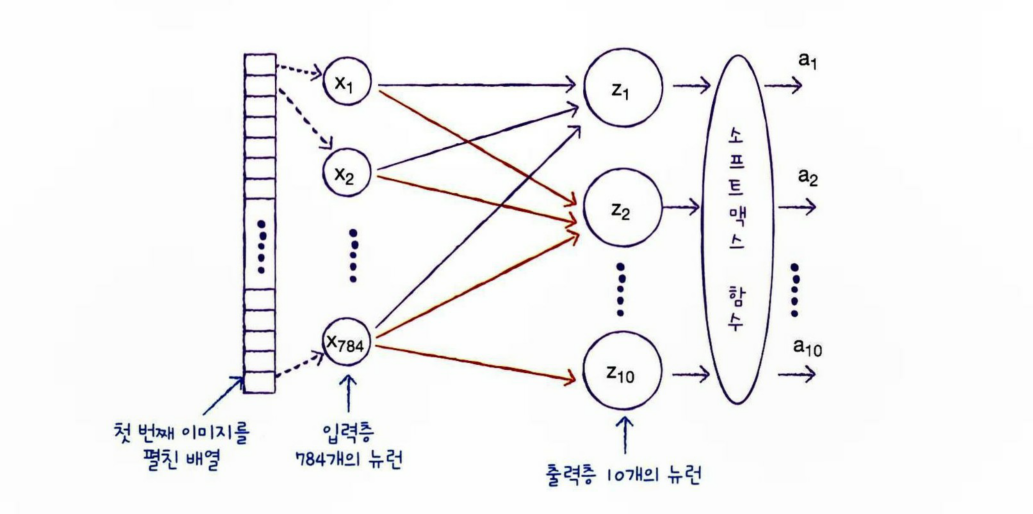

- 활성화 함수(activation function)

    소프트맥스와 같이 뉴런의 선형 방정식 계산 결과에 적용되는 함수 

----

##### 인공 신경망으로 패션 아이템 분류하기

In [20]:
# 케라스 모델 훈련 전 손실함수, 측정값 지정 
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

| 손실 함수 | 타깃 형태 | 사용 상황 |
|:---------:|:---------:|:---------:|
| binary_crossentropy | 0/1 | 이진 분류 |
| categorical_crossentropy | 원-핫 벡터 | 다중 분류 |
| sparse_categorical_crossentropy | 정수 레이블 | 다중 분류(정수 타깃 사용 시) |

`metrics = ['accuracy']` 훈련 시 손실(loss)만 보는 것보다 정확도(acccuracy)도 함께 확인하기 위해 사용

**원-핫 인코딩(One-Hot Encoding)** 정숫값을 배열에서 해당 정수 위치의 원소만 1 이고 나머지는 모두 0으로 변환

케라스에서는 ‘sparse_categorical_entropy’ 손실을 지정하면 이런 변환을 수행할 필요가 없음

In [21]:
# 모델 훈련 
# fit(입력값, 타깃값, epochs=에포크횟수)
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7390 - loss: 0.7808
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8360 - loss: 0.4874
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8461 - loss: 0.4486
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8508 - loss: 0.4416
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8544 - loss: 0.4335


In [22]:
# 검증 세트에서 모델의 성능 평가
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8528 - loss: 0.4430


[0.4529575705528259, 0.8484166860580444]

---

#### 7-2. 심층 신경망

In [23]:
# 패션 MNIST 데이터셋 불러오기 
import keras
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()

In [24]:
# 훈련 세트와 검증 세트 구분
from sklearn.model_selection import train_test_split

train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)


- 은닉층(hidden layer)

    입력층과 출력층 사이에 있는 모든 층

In [25]:
# 시그모이드 활성화 함수를 사용한 은닉층과 소프트맥스 함수를 사용한 출력층을 케라스의 Dense 클래스로 생성
inputs = keras.layers.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='sigmoid')
dense2 = keras.layers.Dense(10, activation='softmax')

---

##### 심층 신경망 만들기

In [26]:
# 심층 신경망 생성
model = keras.Sequential([inputs, dense1, dense2])

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

- 출력 크기(샘플의 개수, 뉴런 개수)

    케라스 모델의 fit()메서드에 훈련 데이터를 주입하면 미니배치 경사 하강법을 사용 

    케라스의 기본 미니배치 크기는 32개이지만, 샘플 개수를 고정하지 않고 어떤 배치 크기에도 유연하게 대응할 수 있도록 None으로 설정

    이렇게 신경망 층에 입력되거나 출력되는 배열이 첫번째 차원을 **배치 차원**이라고 부름 

- 모델 파라미터 개수 

    (입/출력 픽셀 x 뉴런 개수) + 뉴런 당 절편 1개 

- Non-trainable params: 훈련되지 않는 파라미터를 가진 층 

In [28]:
# 층을 추가하는 다른 방법(1) - Sequential 클래스의 생성자 안에서 바로 클래스의 객체 만들기
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(100, activation='sigmoid', name='은닉층'),
    keras.layers.Dense(10, activation='softmax', name='출력층')
], name='패션 MNIST 모델')

In [29]:
model.summary()

Model: "패션 MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 은닉층 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 출력층 (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# 층을 추가하는 다른 방법(2) - add()메서드
model = keras.Sequential()
model.add(keras.layers.Input(shape=(784,)))
model.add(keras.layers.Dense(100, activation='sigmoid'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [31]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# 모델 훈련
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7538 - loss: 0.7628
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8491 - loss: 0.4236
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8619 - loss: 0.3855
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8718 - loss: 0.3601
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8776 - loss: 0.3362


---

##### ReLU(Rectified Linear Unit) 함수

신경망에서 가장 널리 쓰이는 활성화 함수 중 하나로, 입력값을 0과 비교하여 출력값을 결정

| 함수          | 정의                                           | 출력 범위   | 특징                                            |
| ----------- | -------------------------------------------- | ------- | --------------------------------------------- |
| **ReLU**    | $( f(x) = \max(0, x) )$                        | [0, ∞)  | 계산 빠름, 그래디언트 소실 문제 완화, 음수 구간 Dead ReLU 가능     |
| **Sigmoid** | $( f(x) = \frac{1}{1 + e^{-x}} )$              | (0, 1)  | 확률 해석 가능, 입력 절댓값 크면 그래디언트 소실                  |
| **Tanh**    | $( f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} )$ | (-1, 1) | 출력 평균 0, Sigmoid보다 수렴 속도 빠름, 큰 입력에서는 그래디언트 소실 |


In [33]:
# Flatten 클래스: 배치 차원을 제외하고 나머지 입력 차원을 모두 일렬로 펼치는 역할
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28)))
model.add(keras.layers.Flatten())               # Flatten 클래스는 학습하지 않음 
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [34]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

케라스 API는 입력 데이터에 대한 전처리 과정을 될 수 있으면 모델에 포함

In [35]:
# 모델 재훈련
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [36]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7673 - loss: 0.6632
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8529 - loss: 0.4012
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8725 - loss: 0.3539
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8809 - loss: 0.3333
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8848 - loss: 0.3171


In [37]:
# 검증 세트에서의 성능 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8732 - loss: 0.3619


[0.36461853981018066, 0.8712499737739563]

---

##### 옵티마이저
 신경망 학습 과정에서 손실 함수를 최소화하도록 모델의 가중치를 조정하는 알고리즘

하이퍼파라미터 : 추가할 은닉층의 개수, 은닉층의 뉴런 개수, 활성화 함수, 층의 종류, batch_size 매개변수, epochs 매개변수, RMSprop의 학습률 등 

```python
# SGD 옵티마이저 사용하기 (1)
model.compilr(optimizer='sgd', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

```python
# SGD 옵티마이저 사용하기 (2)
sgd = keras.oprimizers.SGD(learning_rate=0.1)           # 학습률 기본값 0.01
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

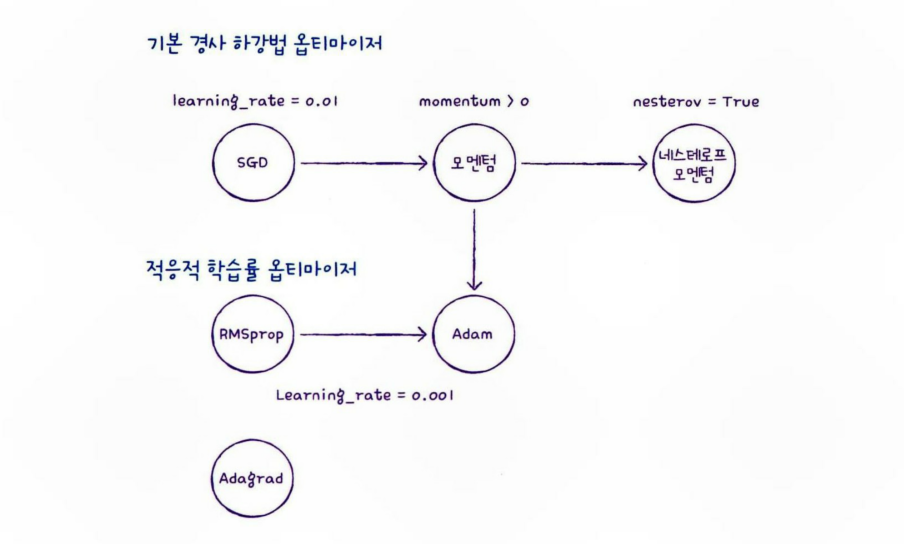

1) SGD(Stochastic Gradient Descent)

- 기본 경사하강법 제공.

- 모멘텀 최적화: 이전 기울기를 가속도로 활용하여 수렴 속도 향상 <br>
    보통 momentum 매개변수는 0.9이상을 지정

- 네스테로프 모멘텀 최적화(네스테로프 가속 경사) → 모멘텀의 단점을 보완하여 더 빠르고 안정적 수렴
    ```python
    sgd = keras.oprimizers.SGD(momentum=0.9, nesterov=True)

2) 적응적 학습률(Adaptive Learning Rate)

- 최적점에 가까워질수록 자동으로 학습률 감소

- 별도 튜닝 부담을 줄여 안정적 학습 가능

- 대표 알고리즘

    - Adagrad

    - RMSprop (Keras 기본 옵티마이저) → 둘 모두 learning_rate=0.001 기본값

```python
adagrad = keras.optimizers.Adagrad() 
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

```python
rmsprop = keras. optimizers. RMSprop()
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

3) Adam

- 모멘텀 + RMSprop 장점 결합

- 실무에서 가장 먼저 시도할 만한 최적화 알고리즘.

- 기본 학습률: 0.001

| 알고리즘               | 특징                   |
| ------------------ | ------------------------------------------------------------ |
| **SGD**            | 기본 경사하강법             |
| **SGD + Momentum** | 기울기 누적 → 빠른 수렴       |
| **Nesterov**       | 예측 기반 업데이트 → 더 안정적   |
| **Adagrad**        | 적응적 학습률, 자동 조정       |
| **RMSprop**        | 변화 큰 가중치만 선택적 조정     |
| **Adam**           | 모멘텀 + RMSprop, 기본 추천 |


In [38]:
# Adam 클래스의 매개변수 기본값을 사용해 패션 MNIST 모델 훈련
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [39]:
# compile() 메서드의 optimizer를 'adam'으로 설정하고 5번의 에포크동안 훈련
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7660 - loss: 0.6723
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8562 - loss: 0.4044
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8692 - loss: 0.3594
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8818 - loss: 0.3232
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8879 - loss: 0.3085


In [40]:
# 검증 세트 성능 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8852 - loss: 0.3269


[0.32996758818626404, 0.8818333148956299]

---

#### 7-3. 신경망 모델 훈련

##### 손실 곡선

케라스의 fit()메서드는 History 클래스의 객체를 반환

History 객체에는 훈련 과정에서 계산한 지표, 즉 손실과 정확도 값이 저장되어 있음

In [41]:
# 데이터를 적재하고 훈련 세트와 검증 세트로 구분
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [42]:
# 모델을 만드는 간단한 함수 정의
def model_fn(a_layer=None):     # 은닉 층 뒤에 또 하나의 층을 추가 
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28,28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu'))
    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model             

In [43]:
model = model_fn()
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# fit() 메서드의 결과를 history 변수에 적재
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=5, verbose=0)    # verbose 훈련 과정 출력 조절
                                                                        # 0 훈련 과정 나타내지 않음
                                                                        # 1 진행 막대와 함께 지표 출력
                                                                        # 2 진행 막대빼고 출력

In [45]:
# history 딕셔너리 값 확인
# 케라스는 기본적으로 에포크마다 손실 계산
# 정확도는 compile() 메서드에서 metrics 매개변수에 'accuracy'를 추가했기 때문에 생성됨
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


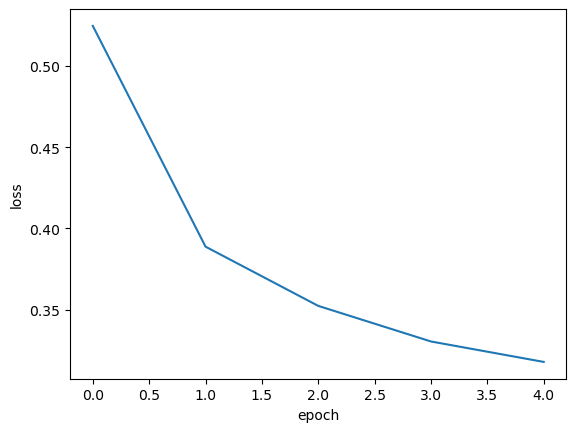

In [46]:
# 손실 그래프 그리기 
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')         # 5개의 에포크 
plt.ylabel('loss')          # 계산된 손실값
plt.show()

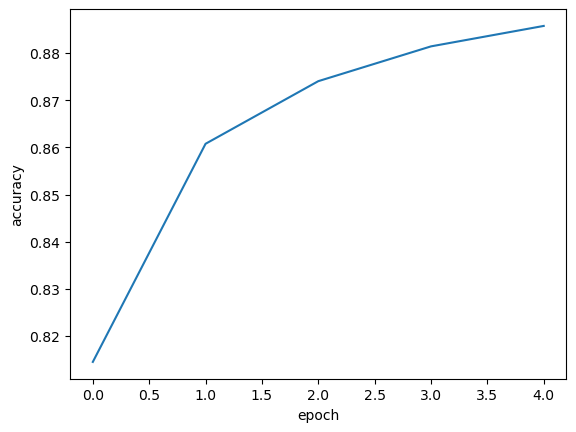

In [47]:
# 정확도 그래프 그리기 
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')             # 5개의 에포크 
plt.ylabel('accuracy')          # 정확도
plt.show()

에포크마다 **손실이 감소하고 정확도가 향상**하는 것을 확인 가능

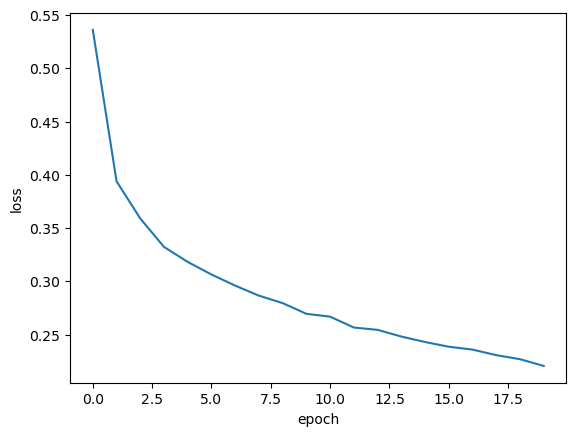

In [48]:
# 에포크 횟수를 늘려 모델을 훈련하고 손실 그래프 그리기
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

---

##### 검증 손실

SGD 사용하여 신경망을 학습할 때 

| 학습 단계 | 에포크 수 | 모델 상태   | 특징                                                      |
| ----- | ----- | ------- | ------------------------------------------------------- |
| 초기    | 1~몇 회 | 과소적합    | 모델이 데이터 패턴을 충분히 학습하지 못함. 손실 높음, 정확도 낮음                  |
| 적정    | 중간    | 적합(fit) | 손실이 점차 감소하고 검증 정확도 상승. 학습과 일반화 균형                       |
| 과도    | 많음    | 과대적합    | 훈련 데이터 손실 낮음, 정확도 높음, 검증 데이터 성능 감소. 모델이 훈련 데이터에 지나치게 맞춤 |

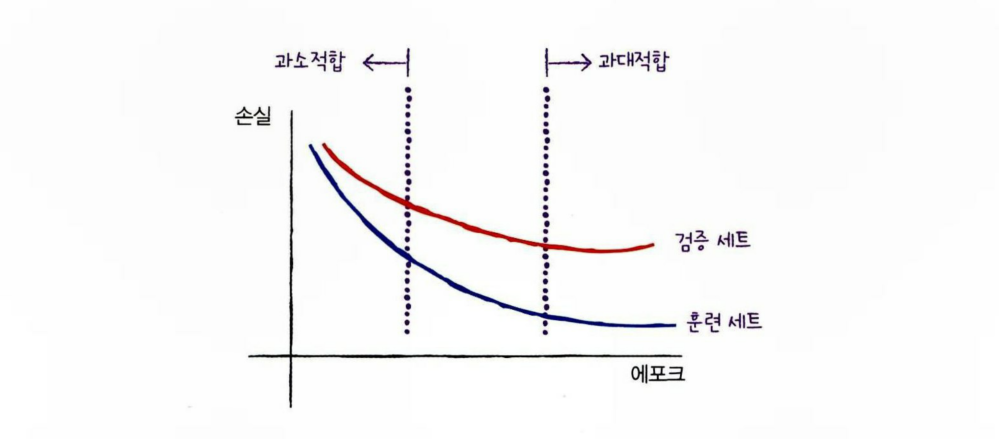

인공 신경망 모델이 최적화하는 대상은 정확도가 아니라 손실 함수 

손실 감소에 비례하여 정확도가 높아지지 않는 경우도 발생 

**모델이 잘 훈련되었는지 판단하려면 정확도보다는 손실 함수의 값을 확인**하는 것이 더 나음

In [49]:
# 에포크마다 검증 손실 계산하기 
# validation_data 매개변수에 검증에 사용할 입력과 타깃값을 튜플로 만들어 전달 
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

In [50]:
# 딕셔너리 값 확인
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


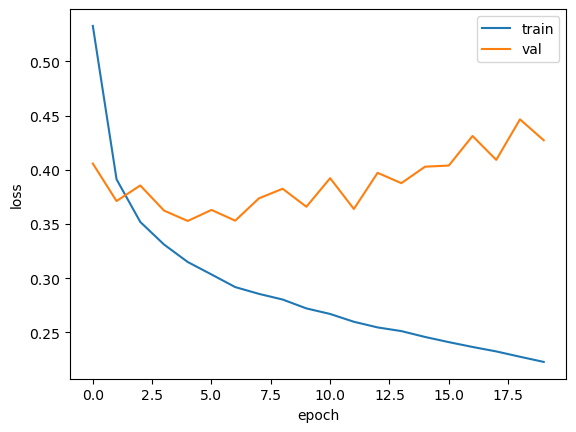

In [51]:
# 과대/과소적합 문제 조사 
# 훈련 손실과 검증 손실을 한 그래프에 그려서 비교
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

초기에 검증 손실이 감소하다가 다섯 번째 에포크 만에 다시 상승하고, 훈련 손실은 꾸준히 감소 

→ 전형적인 **과대적합** 모델

검증 손실이 상승하는 시점을 가능한 뒤로 늦추면 검증 세트에 대한 손실이 줄어들 뿐만 아니라 검증 세트에 대한 정확도도 증가 

= 모델이 더 일반화되도록 안정적으로 학습하고, 검증 정확도를 최대화

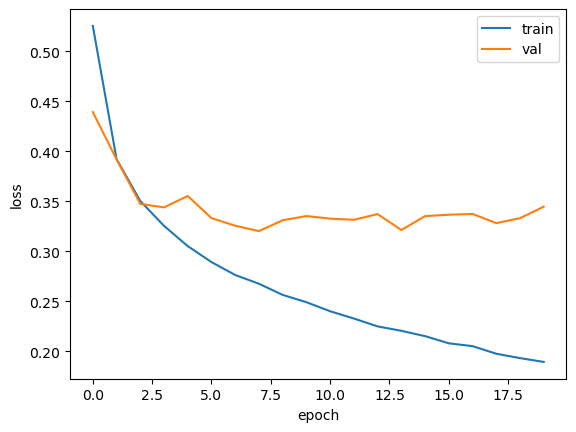

In [52]:
# 옵티마이저 하이퍼파라미터를 조정하여 과대적합 완화 시도 
# 기본 RMSprop 옵티마이저는 많은 문제에서 잘 동작
# Adam은 적응적 학습률을 사용하기 때문에 에포크가 진행되면서 학습률의 크기 조정 가능
# 더 나은 손실 곡선을 얻으려면 학습률을 조정해서 재시도 
model = model_fn()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

---

##### 드롭아웃 

훈련 과정에서 층에 있는 일부 뉴런의 출력을 0으로 만들어 과대 적합을 막음

이전 층의 일부 뉴런이 랜덤하게 꺼지면 특정 뉴런에 과대하게 의존하는 것을 줄일 수 있고 모든 입력에 대한 주의를 기울여야 하기 때문에 과대적합을 줄이고 더 안정적인 예측을 만들 수 있음

In [53]:
# 모델의 30%를 드롭아웃
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

은닉층 뒤의 드롭아웃 층은 훈련되는 모델 파라미터가 없으며 입력과 출력의 크기가 같음

일부 뉴런의 출력을 0으로 만들지만 전체 출력 배열의 크기는 변하지 않음

훈련이 끝난 뒤에 평가나 예측을 수행할 때는 드롭아웃을 적용하면 안됨 → **훈련된 모든 뉴런을 사용해야 올바른 예측 수행 가능**

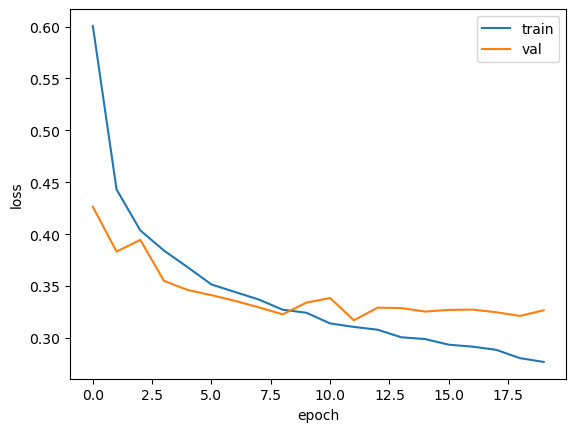

In [54]:
# 훈련 손실과 검증 손실의 그래프 비교 
# 케라스는 모델을 평가와 예측에 사용할 때는 자동으로 드롭아웃을 적용하지 않음 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

---

##### 모델 저장과 복원

In [55]:
# 에포크 횟수를 11로 다시 지정하고 훈련하기 위해 기존 모델 저장
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=11, verbose=0,
                    validation_data=(val_scaled, val_target))

In [56]:
# 모델 구조와 파라미터를 함께 저장 
model.save('model-whole.keras')

In [57]:
# 훈련된 모델의 파라미터만 저장
model.save_weights('model.weights.h5')

In [58]:
# 저장된 파일 확인
!ls -al model*

-rw-r--r-- 1 ai_study ai_study 979393 Nov 28 09:24 model-whole.keras
-rw-r--r-- 1 ai_study ai_study 976600 Nov 28 09:24 model.weights.h5


In [59]:
# 새로운 모델을 h5파일에서 훈련된 모델 파라미터를 읽어서 사용
model = model_fn(keras.layers.Dropout(0.3))
model.load_weights('model.weights.h5')

In [60]:
# 검증 정확도 확인
# 10개 확률 중에 가장 큰 값의 인덱스를 골라 타깃 레이블과 비교하여 정확도 계산
import numpy as np

val_labels = np.argmax(model.predict(val_scaled), axis=-1)      # argmax() 가장 큰 값의 인덱스 반환
                                                                # axis=-1 배열의 마지막 차원(열)을 따라 최댓값 선택
print(np.mean(val_labels == val_target))                        # 인덱스와 타깃을 비교, 위치가 같으면 1 다르면 0

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
0.88575


In [61]:
# 모델 전체를 파일에서 읽은 후 검증 세트의 정확도 출력
model = keras.models.load_model('model-whole.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8874 - loss: 0.3186


[0.3237513303756714, 0.8857499957084656]

---

##### 콜백
훈련 과정 중간에 어떤 작업을 수행할 수 있게 하는 객체 

In [ ]:
# ModelCheckpoint 콜백: 기본적으로 에포크마다 모델을 저장
# save_best_only=True 매개변수를 지정하여 가장 낮은 검증 손실을 만드는 모델 저장 가능
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)
model.fit(train_scaled, train_target, epochs=20, verbose=0,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])

In [63]:
# 예측 수행
model = keras.models.load_model('best-model.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8912 - loss: 0.3158


[0.31959274411201477, 0.8882499933242798]

---

##### 조기 종료

과대 적합이 시작되기 전에 훈련을 미리 중지 

훈련 에포크 횟수를 제한하는 역할이지만 모델이 과대적합되는 것을 막아 주기 때문에 규제 방법 중 하나로 생각할 수 있음

EarlyStopping 콜백과 ModelCheckpoint 콜백을 함께 사용하면 가장 낮은 검증 손실의 모델을 파일에 저장하고 <br>검증 손실이 다시 상승할 때 훈련을 중지할 수 있음

또한 훈련을 중지한 다음 현재 모델의 파라미터를 최상의 파라미터로 되돌림

In [75]:
# EarlyStopping 콜백: patience 배개변수는 검증 점수가 향상되지 않더라도 참을 에포크 횟수로 지정 
# restore_best_weights 배개변수를 True로 지정하면 가장 낮은 검증 손실을 낸 모델 파라미터로 복구 
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

In [76]:
# 몇 번째 에포크에서 훈련이 중지되었는지 확인
print(early_stopping_cb.stopped_epoch)

12


13번째 에포크에서 훈련이 중지되었으며, 최상의 모델은 11번째 에포크일 것으로 예측 가능

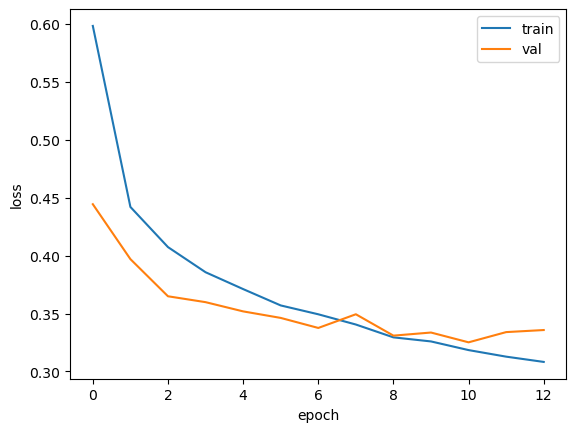

In [77]:
# 훈련 손실과 검증 손실을 출력
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

조기 종료 기법을 사용하면 안심하고 에포크 기법을 크게 지정해도 상관 없음

In [78]:
# 조기 종료로 얻은 모델을 사용해 검증 세트 성능 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8822 - loss: 0.3222


[0.3251681625843048, 0.8809166550636292]